In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score


## Uppgift: Klustring med K-Means

Ett företag har information om sina kunder, men ingen target-variabel. Företaget vill förstå om det finns olika typer av kunder.

Er uppgift är att använda klustring för att försöka hitta dessa grupper. Arbeta tillsammans i gruppen och diskutera era val.

Vi skapar ett dataset med make_blobs.

In [2]:
from sklearn.datasets import make_blobs

X, y_target = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.5,
    random_state=1337
)

Undersök: vilket k vi ska välja

* Testa olika värden för k
* Beräkna intertia
* Beräkna silhouette score
* Gör ett silhouette diagram
* Visualisera klustren
* Motivera och argumentera för val av k

Diskutera i gruppen:

* Om inertia säger k=5, medan silhouette score och er visuella bedömning säger k=4 – vilket väljer ni?
* Om vi hittar 5 statistiskt tydliga kluster men experter inom området bara kan tolka 3 av dem – vilket K skulle ni välja?
* Kan ett kluster vara statistiskt bra men ändå vara meningslöst i praktiken?

In [3]:
# sätter upp KMeans för ett enskilt k
k = 4
kmeans = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=1337)
y_kmeans = kmeans.fit_predict(X)

ValueError: 'virids' is not a valid value for cmap; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r

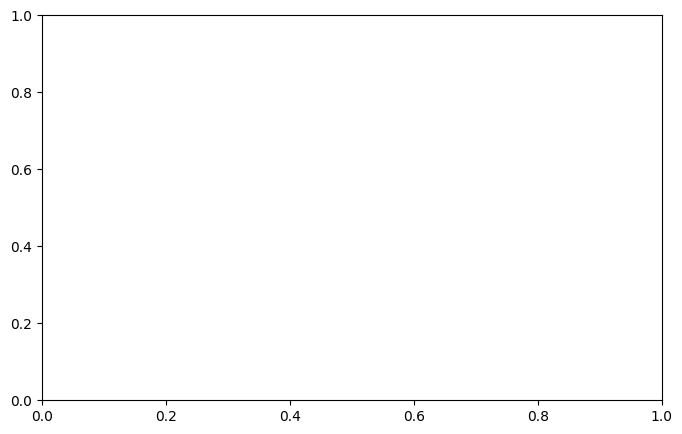

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=200, marker='X')
plt.title("K-means Klustring")

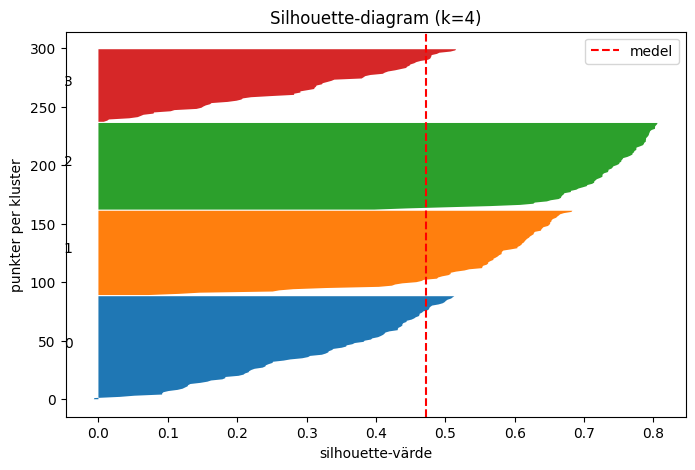

In [ ]:
# Silhouette-diagram för valt k (ändra k och jämför)
k = 4
km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=1337)
labels = km.fit_predict(X)
sample_sil = silhouette_samples(X, labels)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 0
for i in range(k):
    vals = np.sort(sample_sil[labels == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(range(y_lower, y_upper), 0, vals)
    ax.text(-0.05, y_lower + len(vals) / 2, str(i))
    y_lower = y_upper

ax.axvline(silhouette_score(X, labels), color="red", linestyle="--", label="medel")
ax.set(title=f"Silhouette-diagram (k={k})", xlabel="silhouette-värde", ylabel="punkter per kluster")
ax.legend()
plt.show()

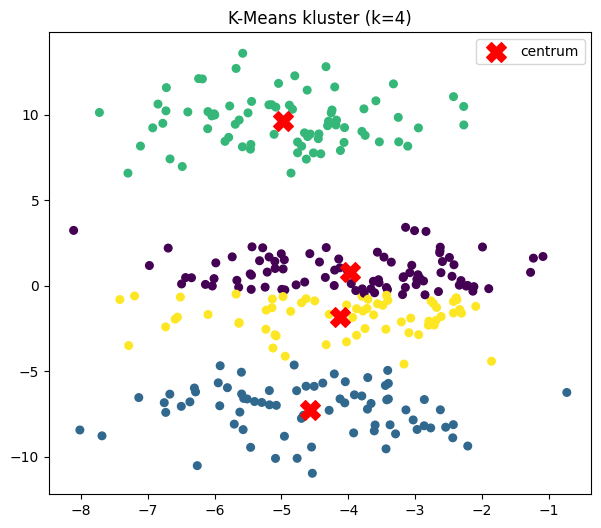

In [ ]:
# Visualisera klustren (X är redan 2D, så PCA behövs egentligen inte här)
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=30)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c="red", marker="X", s=200, label="centrum")
plt.title(f"K-Means kluster (k={k})")
plt.legend()
plt.show()